In [ ]:
import sys

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')


from Interpretation.Plotting.src import (load_stablity_error_data, plot_stablity_error,\
                               load_enrichment_data, plot_enrichment,\
                               load_perturbation_data, plot_perturbation,\
                               load_explained_variance_data,plot_explained_variance, programs_dotplots, \
                               plot_k_selection_panel,plot_k_selection_panel_no_traits
                          )

In [4]:
%pip install svglib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.5/662.5 kB 92.0 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [49 lines of output]
      + meson setup /tmp/pip-install-xph0yxft/pycairo_a84ded57ac6a4c3e8c2429e8a583e1be /tmp/pip-install-xph0yxft/pycairo_a84ded57ac6a4c3e8c2429e8a583e1be/.mesonpy-4ad45e1f -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md -Dwheel=true -Dtests=false --native-file=/tmp/pip-install-xph0yxft/pycairo_a84ded57ac6a4c3e8c2429e8a583e1be/.mesonpy-4ad45e1f/meson-python-native-file.ini
      The Meson build system
      Version: 1.10.2
      Source dir: /tmp/pip-install-xph0yxft/pycairo_a84ded57ac6a4c3e8c2429e8a583e1be
      Build dir: /tmp/pip-install-xph0yxft/pycairo_a84ded57ac6a4c3e8c242

In [ ]:
output_directory = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/012726_100k_cells_20iter_allHVG_torch_halsvar_batch_e7"
run_name = "012726_100k_cells_20iter_allHVG_torch_halsvar_batch_e7_all"
folder = f"{output_directory}/{run_name}/Evaluation"
components = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300]
sel_threshs = [0.2]

# Stability & Error

In [ ]:
#stats = load_stablity_error_data( output_directory = output_directory, run_name = run_name, components = components)

# For torch-cNMF runs where the cnmf package is not installed, you can provide
# a pre-computed stability/error file (TSV or NPZ) via the stability_file parameter:
stats = load_stablity_error_data(output_directory=output_directory, run_name=run_name, components=components,
     stability_file=f"{output_directory}/{run_name}/{run_name}.k_selection_stats.df.npz")

stats

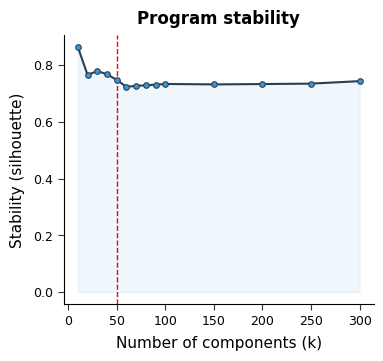

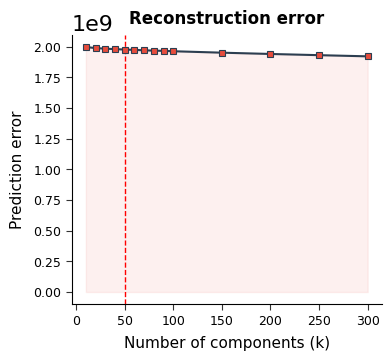

In [5]:
plot_stablity_error(stats, selected_k = 50)

# Enrichement tests

In [ ]:
# Default (IGVF convention): uses {k}_GO_term_enrichment.txt, {k}_geneset_enrichment.txt, {k}_trait_enrichment.txt
# with columns: Term, Adjusted P-value
count_df = load_enrichment_data(folder, components = components,  sel_thresh = 0.2, pval = 0.05)

# For non-default file names / column names (e.g. Morphic data), use:
# count_df = load_enrichment_data(folder, components = components, sel_thresh = 2.0, pval = 0.05,
#     go_file='cNMF_GO_Biological_Process_2023_fisher_geneset_enrichment.txt',
#     geneset_file='cNMF_Reactome_2022_fisher_geneset_enrichment.txt',
#     trait_file='cNMF_OT_GWAS_fisher_trait_enrichment.txt',
#     term_col='term',
#     adjpval_col='adj_pval')

plot_enrichment(count_df, selected_k = None)

# Perturbation

In [ ]:
# Default (IGVF convention): uses {k}_perturbation_association_results_{sample}.txt
# with columns: adj_pval, target_name, log2FC
test_stats_df = load_perturbation_data(folder, components = components, pval = 0.05, sel_thresh = 0.2, samples = ['d0', 'd1', 'd2', 'd3'])

# For non-default file names / column names (e.g. Morphic data), use:
# test_stats_df = load_perturbation_data(folder, components = components, pval = 0.05, sel_thresh = 2.0,
#     samples = ['D-1', 'D3', 'D5', 'D7', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D18', 'D21', 'D25', 'D26', 'D35'],
#     perturbation_file='cNMF_gene_time_point_{sample}_perturbation_association.txt',
#     perturb_adjpval_col='adj_pval', perturb_target_col='target_name', perturb_log2fc_col='log2FC')

plot_perturbation(test_stats_df, pval = 0.05, selected_k = None)

# Explained Variance

In [ ]:
# Default: {k}_Explained_Variance_Summary.txt with 'Total' column
stats_EV = load_explained_variance_data(folder, components=components, sel_thresh = 0.2)

# For Morphic data (per-program variance_explained_ratio, summed across programs):
# stats_EV = load_explained_variance_data(folder, components=components, sel_thresh = 2.0,
#     variance_file='cNMF_variance_explained_ratio.txt',
#     variance_col='variance_explained_ratio')

plot_explained_variance(stats_EV, selected_k = None)

# All plots

In [ ]:
plot_k_selection_panel_no_traits(stats, count_df, test_stats_df, stats_EV,
                           pval=0.05, folder_name=None, file_name=None, selected_k=50)

/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src/Interpretation/src/k_selection_plots.py:425: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.lineplot(x='K', y='target_name', hue='sample', data=plotting_df_sample,


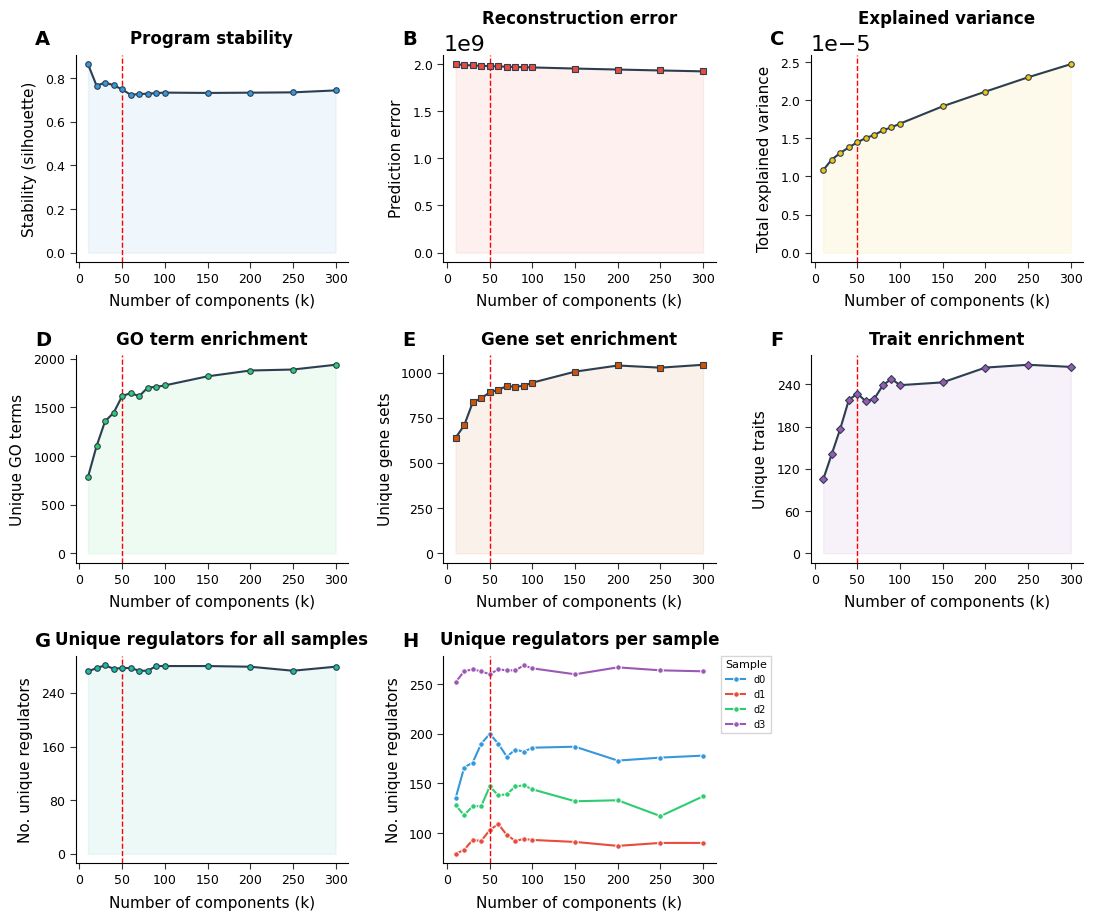

In [9]:
plot_k_selection_panel(stats, count_df, test_stats_df, stats_EV,
                           pval=0.05, folder_name=None, file_name=None, selected_k=50)

# plot dot plots

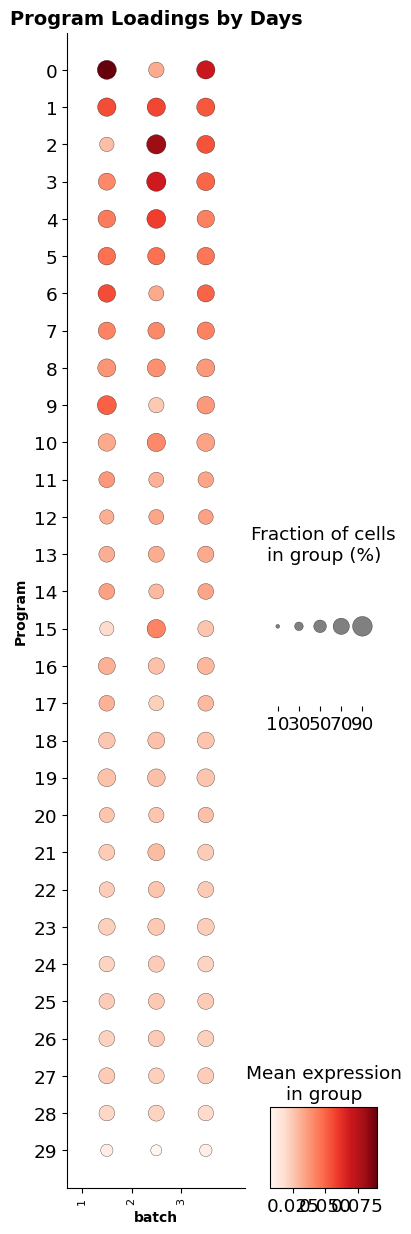

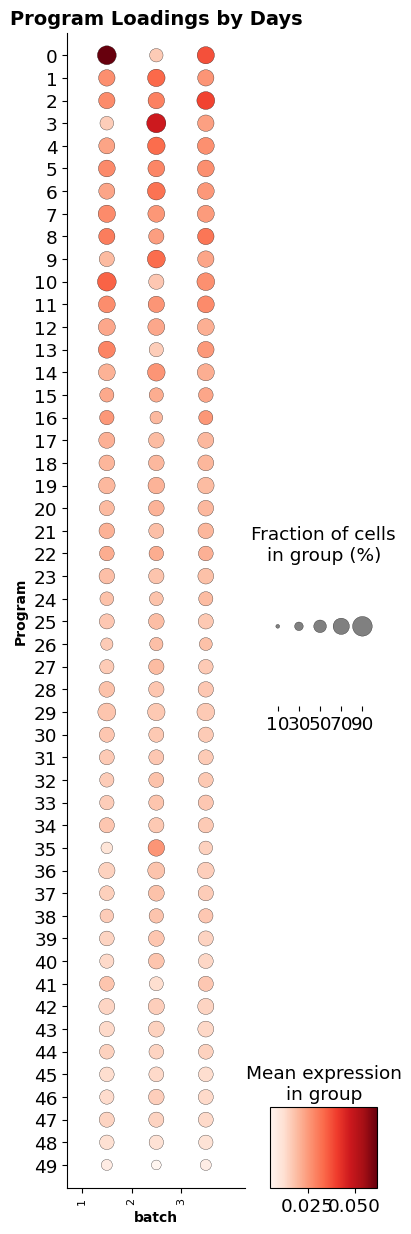

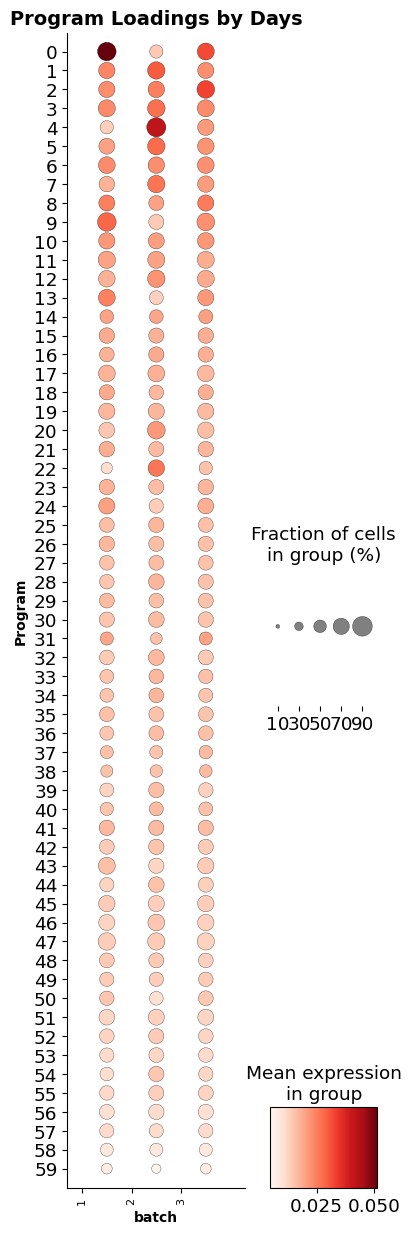

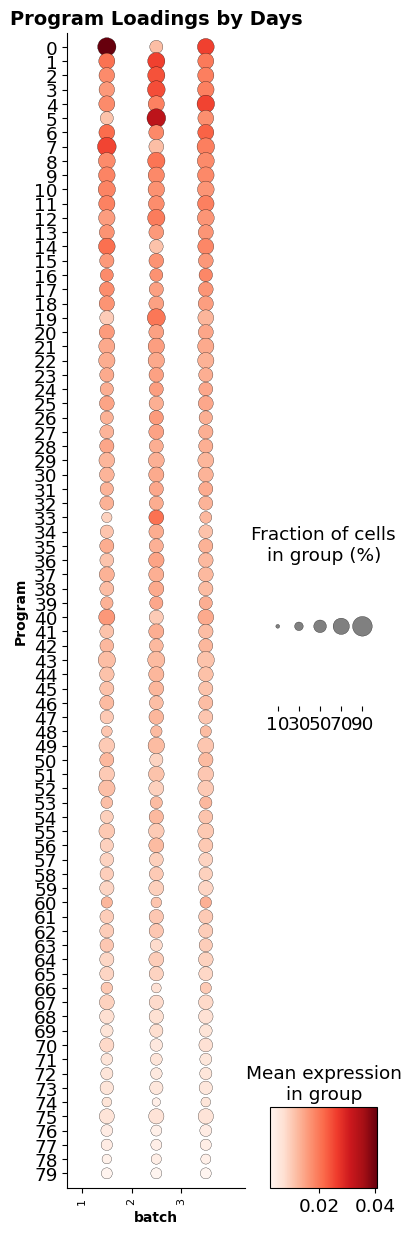

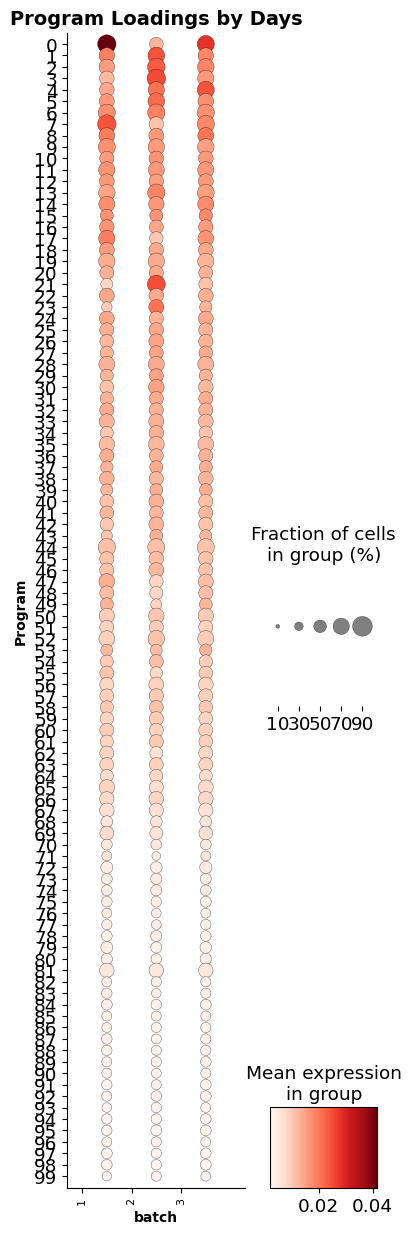

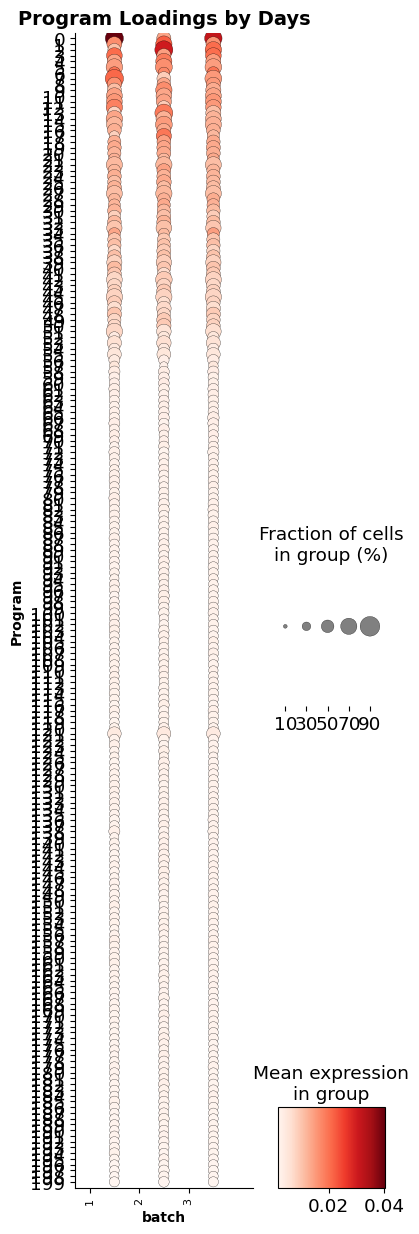

In [8]:
for sel_thresh in sel_threshs:
    for k in components:
        fig = programs_dotplots(k, output_directory, run_name, sel_thresh = 2.0, groupby='batch', figsize=(4, 15))

# Motif (working in progress for complie the results)

In [20]:
def collect_motif_data(k, path):

    motif_enrichment_data = []

    path = f'{path}/{k}'

    # import data 
    for fil in os.listdir(path):
        if 'motif_enrichment' in fil:
            motif_enrichment_data_ = pd.read_csv('{}/{}'.format(path,fil), sep='\t')
            motif_enrichment_data_['sample'] = fil.split('sample_')[-1].split('_motif')[0]
            if 'promoter' in fil:
                motif_enrichment_data_['class'] = 'promoter'
            elif 'enhancer' in fil:
                motif_enrichment_data_['class'] = 'enhancer'            

            motif_enrichment_data.append(motif_enrichment_data_)

    motif_enrichment_data = pd.concat(motif_enrichment_data, ignore_index=True)
    motif_enrichment_data.rename(columns={"adj_pval": "Adjusted P-value"}, inplace=True)

    motif_enrichment_data.to_csv(f'{path}/{k}_motif_enrichment.txt', sep='\t')
    motif_enrichment_data.loc[motif_enrichment_data['class']=='promoter'].to_csv(f'{path}/{k}_motif_enrichment_promoter.txt', sep='\t')
    motif_enrichment_data.loc[motif_enrichment_data['class']=='enhancer'].to_csv(f'{path}/{k}_motif_enrichment_enhancer.txt', sep='\t')


    # Make summary table column
    for seq_class in ['promoter', 'enhancer']:
        motif_enrichment_data_ = motif_enrichment_data.loc[motif_enrichment_data['class']==seq_class]
        motif_enrichment_data_ = motif_enrichment_data_.groupby(['sample', 'program_name', 'motif']).min().reset_index()

        motif_summary_data = pd.DataFrame(index=motif_enrichment_data_.program_name.unique(), columns=['top10_motifs', 'num_enriched_motifs'])
        for prog in motif_enrichment_data_.program_name.unique():
            motif_summary_data_ = motif_enrichment_data_.loc[(motif_enrichment_data_.program_name==prog) & ((motif_enrichment_data_["Adjusted P-value"]<=0.05))]
            motif_summary_data_ = motif_summary_data_.sort_values('stat', ascending=False).head(10).motif.values
            motif_summary_data.loc[prog,'top10_motifs'] = ', '.join(motif_summary_data_.tolist())
            motif_summary_data.loc[prog, 'num_enriched_motifs'] = motif_enrichment_data_.loc[(motif_enrichment_data_.program_name==prog) & ((motif_enrichment_data_.adj_pval<=0.05))].shape[0]
            
        motif_summary_data.to_csv('{}/motif_summary_data_{}.txt'.format(path,seq_class), sep='\t')
        

def collect_motif_all(path, components = [30, 50, 60, 80, 100, 200, 250, 300]):

    for k in components:
        collect_motif_data(k, path)
    
collect_motif_all(path)

In [ ]:
path = '/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Results/torch-cNMF_evaluation/090425_100k_cells_10iter_torch_mu_online/Evaluation/'


collect_motif_data(50,path)

In [4]:
    
# # Copy out to dashboard
# out_dir = '../../shared/250110_ipsc_ec_dashboard_setup/cNMF_100/'
# for fil in os.listdir('cNMF_100'):
#     if 'motif_' in fil:
#         class_ = fil.split('_')[1]
#         name = fil.split('_sample_')[1]
#         new_nam = f'cNMF_100_{class_}_test_pearsonr_sample_{name}'
#         if not name.startswith('D0'):
#             new_nam = new_nam.replace('sample_', 'sample_sample_')
#         os.system('cp {} {}'.format(os.path.join('cNMF_100', fil),
#                                     os.path.join(out_dir, new_nam)))